### DORADO, LOUISE MARIELLE V.
### PONTILLAS, STEVEN KEN E.
### BSCS 3A AI

# Fine-Tuning a Pretrained LLM for Fashion Product Classification

## Submission Title
**Fine-tuning DistilBERT for Fashion Product Classification using the `ashraq/fashion-product-images-small` dataset**

This notebook presents a complete domain-specific fine-tuning workflow using a pretrained Hugging Face language model. The project focuses on classifying fashion product names into fashion product types using only text features from a fashion e-commerce dataset.

# 1. Introduction

Large language models and pretrained transformer models can be adapted to specialized domains through fine-tuning. In this activity, a pretrained DistilBERT model is fine-tuned on a fashion product dataset from Hugging Face. The goal is to classify a product name into its corresponding fashion product type.

Although the dataset also contains images, this notebook uses only the text field `productDisplayName` so that the project remains a natural language processing task. The model is trained to predict the `articleType` label.

# 2. Identified the Task to be Performed

**Task:** Text Classification

The task performed in this activity is **fashion product classification**. The model receives a product name as input and predicts the corresponding product category. This is a supervised multi-class text classification problem.

# 3. Identified the Domain Used for Fine-Tuning

**Domain:** Fashion / E-commerce

The domain used for fine-tuning is the **fashion and e-commerce domain**. The dataset contains fashion product metadata such as product names and category labels. This makes it appropriate for domain-specific fine-tuning.

# 4. Identified the LLM / Pretrained Model to be Used

**Pretrained Model:** `distilbert-base-uncased`

The pretrained language model used in this notebook is **DistilBERT**, specifically the `distilbert-base-uncased` checkpoint from Hugging Face. DistilBERT is a smaller and faster version of BERT, making it practical for classroom experimentation and laptop-based fine-tuning.

# 5. Established the Configuration Needed for Fine-Tuning

The following configuration is used for fine-tuning:

- **Tokenizer:** DistilBERT tokenizer
- **Maximum sequence length:** 32
- **Learning rate:** 2e-5
- **Training batch size:** 16
- **Evaluation batch size:** 16
- **Epochs:** 3
- **Weight decay:** 0.01
- **Train-test split:** 80% training, 20% testing
- **Evaluation metrics:** Accuracy, Precision, Recall, and Weighted F1-score

To make training easier on a regular laptop, only the **top 10 most frequent `articleType` classes** are retained.

In [1]:
%pip install -q transformers datasets evaluate scikit-learn matplotlib pandas numpy torch accelerate

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import evaluate

from datasets import load_dataset, Dataset, DatasetDict
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix, ConfusionMatrixDisplay
from sklearn.decomposition import PCA
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

pd.set_option("display.max_colwidth", 120)
set_seed(42)


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


# 6. Library Installation and Imports

The code cell above installs and imports the required libraries for data loading, preprocessing, model training, evaluation, and PCA visualization.

In [2]:
# Load the dataset from Hugging Face
raw_dataset = load_dataset("ashraq/fashion-product-images-small", split="train")

# Convert to pandas and keep only the needed text and label columns
df = raw_dataset.to_pandas()[["productDisplayName", "articleType"]].copy()

print("Original dataset shape:", df.shape)
display(df.head())

print("\nMissing values per column:")
print(df.isna().sum())

print("\nTop article types before filtering:")
display(df["articleType"].value_counts().head(15).to_frame("count"))

Original dataset shape: (44072, 2)


,productDisplayName,articleType
0,Turtle Check Men Navy Blue Shirt,Shirts
1,Peter England Men Party Blue Jeans,Jeans
2,Titan Women Silver Watch,Watches
3,Manchester United Men Solid Black Track Pants,Track Pants
4,Puma Men Grey T-shirt,Tshirts



Missing values per column:
productDisplayName    0
articleType           0
dtype: int64

Top article types before filtering:


,count
articleType,
Tshirts,7065
Shirts,3212
Casual Shoes,2845
Watches,2542
Sports Shoes,2016
Kurtas,1844
Tops,1762
Handbags,1759
Heels,1323


# 7. Load and Inspect the Dataset

The dataset is loaded from Hugging Face using `load_dataset`. Only the text column `productDisplayName` and the label column `articleType` are used. This keeps the project focused on text classification rather than image classification.

In [3]:
# Ensure expected columns exist when rerunning this cell after partial executions
if "articleType" not in df.columns:
    if isinstance(df.index, pd.MultiIndex) and "articleType" in df.index.names:
        df = df.reset_index()
    elif "raw_dataset" in globals():
        df = raw_dataset.to_pandas()[["productDisplayName", "articleType"]].copy()
    else:
        raise KeyError("Missing articleType column in df")

# Clean the text and labels
df["productDisplayName"] = (
    df["productDisplayName"]
    .fillna("")
    .astype(str)
    .str.lower()
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

df["articleType"] = (
    df["articleType"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# Remove rows with missing or empty values
df = df[(df["productDisplayName"] != "") & (df["articleType"] != "")].copy()

# Keep only the top 10 most frequent classes
top_10_classes = df["articleType"].value_counts().head(10).index.tolist()
df = df[df["articleType"].isin(top_10_classes)].copy()

# Optional sampling per class so the notebook stays practical on a school laptop
MAX_EXAMPLES_PER_CLASS = 400
sampled_groups = [
    g.sample(n=min(len(g), MAX_EXAMPLES_PER_CLASS), random_state=42)
    for _, g in df.groupby("articleType")
]
df = (
    pd.concat(sampled_groups, ignore_index=True)
      .sample(frac=1.0, random_state=42)
      .reset_index(drop=True)
)

print("Cleaned dataset shape:", df.shape)
print("\nClass distribution after filtering:")
display(df["articleType"].value_counts().to_frame("count"))
display(df.head())

Cleaned dataset shape: (4000, 2)

Class distribution after filtering:


,count
articleType,
Handbags,400
Tshirts,400
Watches,400
Tops,400
Casual Shoes,400
Shirts,400
Heels,400
Kurtas,400
Sunglasses,400


,productDisplayName,articleType
0,murcia women grey kate handbag,Handbags
1,nike men green polo tshirts,Tshirts
2,baggit women purple bag,Handbags
3,q&q men black watch,Watches
4,levis kids girl's darcy red teens kidswear,Tops


# 8. Data Cleaning and Preprocessing

The text data is cleaned by lowercasing, trimming extra spaces, and removing rows with empty values. The dataset is then filtered to keep only the top 10 most frequent `articleType` classes. This step simplifies the classification task and makes training more manageable.

In [4]:
# Create label mappings
label_names = sorted(df["articleType"].unique())
label2id = {label: idx for idx, label in enumerate(label_names)}
id2label = {idx: label for label, idx in label2id.items()}

df["label"] = df["articleType"].map(label2id)

print("Label mapping:")
for idx, label in id2label.items():
    print(f"{idx}: {label}")

Label mapping:
0: Casual Shoes
1: Handbags
2: Heels
3: Kurtas
4: Shirts
5: Sports Shoes
6: Sunglasses
7: Tops
8: Tshirts
9: Watches


# 9. Label Encoding

The string labels in `articleType` are converted into numeric IDs because transformer classification models require integer labels during training.

In [5]:
# Split the dataset into train and test sets
train_df, test_df = train_test_split(
    df[["productDisplayName", "articleType", "label"]],
    test_size=0.20,
    random_state=42,
    stratify=df["label"]
)

print("Training set shape:", train_df.shape)
print("Testing set shape:", test_df.shape)

print("\nTraining class distribution:")
display(train_df["articleType"].value_counts().to_frame("count"))

print("\nTesting class distribution:")
display(test_df["articleType"].value_counts().to_frame("count"))

Training set shape: (3200, 3)
Testing set shape: (800, 3)

Training class distribution:


,count
articleType,
Handbags,320
Sports Shoes,320
Sunglasses,320
Shirts,320
Watches,320
Heels,320
Casual Shoes,320
Kurtas,320
Tshirts,320



Testing class distribution:


,count
articleType,
Shirts,80
Sunglasses,80
Watches,80
Handbags,80
Kurtas,80
Casual Shoes,80
Tops,80
Tshirts,80
Heels,80


# 10. Train-Test Split

The cleaned dataset is split into training and testing sets using stratification. Stratification preserves the class distribution across both splits, which leads to a more reliable evaluation.

In [6]:
# Convert pandas DataFrames to Hugging Face Datasets
train_dataset = Dataset.from_pandas(train_df[["productDisplayName", "label"]].reset_index(drop=True))
test_dataset = Dataset.from_pandas(test_df[["productDisplayName", "label"]].reset_index(drop=True))

dataset_dict = DatasetDict({
    "train": train_dataset,
    "test": test_dataset
})

dataset_dict

DatasetDict({
    train: Dataset({
        features: ['productDisplayName', 'label'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['productDisplayName', 'label'],
        num_rows: 800
    })
})

# 11. Convert to Hugging Face Dataset Format

The training and testing data are converted to Hugging Face `Dataset` objects so they can be easily tokenized and passed into the Hugging Face `Trainer` API.

In [7]:
# Load tokenizer
model_name = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(model_name)

MAX_LENGTH = 32

def tokenize_function(batch):
    return tokenizer(
        batch["productDisplayName"],
        truncation=True,
        max_length=MAX_LENGTH
    )

tokenized_datasets = dataset_dict.map(tokenize_function, batched=True)
tokenized_datasets = tokenized_datasets.remove_columns(["productDisplayName"])

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

tokenized_datasets

Map:   0%|          | 0/3200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3200
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 800
    })
})

# 12. Tokenization

The DistilBERT tokenizer converts the product names into token IDs that can be processed by the model. A maximum sequence length of 32 is used because fashion product names are generally short.

In [8]:
# Load the pretrained model for sequence classification
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Model loaded on:", device)
print("Number of labels:", len(label_names))

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
pre_classifier.bias     | MISSING    | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded on: cpu
Number of labels: 10


# 13. Load the Pretrained Model

The pretrained `distilbert-base-uncased` model is loaded and adapted for multi-class sequence classification by setting the number of output labels equal to the number of selected fashion categories.

In [9]:
# Define evaluation metrics
accuracy_metric = evaluate.load("accuracy")

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)

    accuracy = accuracy_metric.compute(predictions=predictions, references=labels)["accuracy"]
    precision, recall, weighted_f1, _ = precision_recall_fscore_support(
        labels,
        predictions,
        average="weighted",
        zero_division=0
    )

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "weighted_f1": weighted_f1
    }

training_args = TrainingArguments(
    output_dir="./fashion_distilbert_outputs",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=25,
    load_best_model_at_end=True,
    metric_for_best_model="weighted_f1",
    report_to="none",
    seed=42
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_datasets["train"],
    eval_dataset=tokenized_datasets["test"],
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print("Trainer is ready.")

Trainer is ready.


# 14. Training Setup

The Hugging Face `Trainer` API is used to fine-tune the model. The chosen hyperparameters are lightweight and appropriate for a normal school laptop. Accuracy, precision, recall, and weighted F1-score are used during evaluation.

# 15. Model Fine-Tuning

The next code cell fine-tunes the pretrained DistilBERT model on the fashion product classification dataset. You should take a screenshot of the training output for your submission.

In [10]:
# Fine-tune the model
train_results = trainer.train()

# Save the final fine-tuned model
trainer.save_model("./fashion_distilbert_finetuned")

train_results

Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,Weighted F1
1,0.163533,0.148685,0.965000,0.968097,0.965000,0.964627
2,0.118972,0.094611,0.977500,0.977520,0.977500,0.977442
3,0.087888,0.092112,0.978750,0.979248,0.978750,0.978697


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=600, training_loss=0.34367127120494845, metrics={'train_runtime': 767.9047, 'train_samples_per_second': 12.502, 'train_steps_per_second': 0.781, 'total_flos': 38284399809600.0, 'train_loss': 0.34367127120494845, 'epoch': 3.0})

# 16. Evaluation

After training, the model is evaluated on the test set using accuracy, precision, recall, and weighted F1-score. You should take a screenshot of the printed metrics below for your submission.

In [11]:
# Evaluate the fine-tuned model with clear summary tables
pred_output = trainer.predict(tokenized_datasets["test"])
predicted_labels = np.argmax(pred_output.predictions, axis=-1)
true_labels = pred_output.label_ids

accuracy = accuracy_metric.compute(predictions=predicted_labels, references=true_labels)["accuracy"]
precision, recall, weighted_f1, _ = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    average="weighted",
    zero_division=0
)

# Overall metrics table
evaluation_results = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Precision", "Recall", "Weighted F1-score"],
        "Value": [accuracy, precision, recall, weighted_f1],
    }
)
evaluation_results["Value"] = evaluation_results["Value"].round(4)
evaluation_results["Percent"] = (evaluation_results["Value"] * 100).round(2).astype(str) + "%"

print("=" * 60)
print("MODEL EVALUATION SUMMARY")
print("=" * 60)
display(evaluation_results)

# Per-class metrics table for clearer interpretation
class_precision, class_recall, class_f1, class_support = precision_recall_fscore_support(
    true_labels,
    predicted_labels,
    labels=list(range(len(label_names))),
    average=None,
    zero_division=0,
)

per_class_results = pd.DataFrame(
    {
        "Class": label_names,
        "Precision": np.round(class_precision, 4),
        "Recall": np.round(class_recall, 4),
        "F1-score": np.round(class_f1, 4),
        "Support": class_support,
    }
).sort_values(by="F1-score", ascending=False)

print("\nPER-CLASS PERFORMANCE (sorted by F1-score)")
display(per_class_results.reset_index(drop=True))

MODEL EVALUATION SUMMARY


,Metric,Value,Percent
0,Accuracy,0.9788,97.88%
1,Precision,0.9792,97.92%
2,Recall,0.9788,97.88%
3,Weighted F1-score,0.9787,97.87%



PER-CLASS PERFORMANCE (sorted by F1-score)


,Class,Precision,Recall,F1-score,Support
0,Handbags,1.0000,1.0000,1.0000,80
1,Sunglasses,1.0000,1.0000,1.0000,80
2,Watches,1.0000,1.0000,1.0000,80
3,Shirts,0.9877,1.0000,0.9938,80
4,Kurtas,1.0000,0.9875,0.9937,80
5,Heels,0.9756,1.0000,0.9877,80
6,Tshirts,0.9875,0.9875,0.9875,80
7,Tops,0.9750,0.9750,0.9750,80
8,Sports Shoes,0.9726,0.8875,0.9281,80
9,Casual Shoes,0.8941,0.9500,0.9212,80


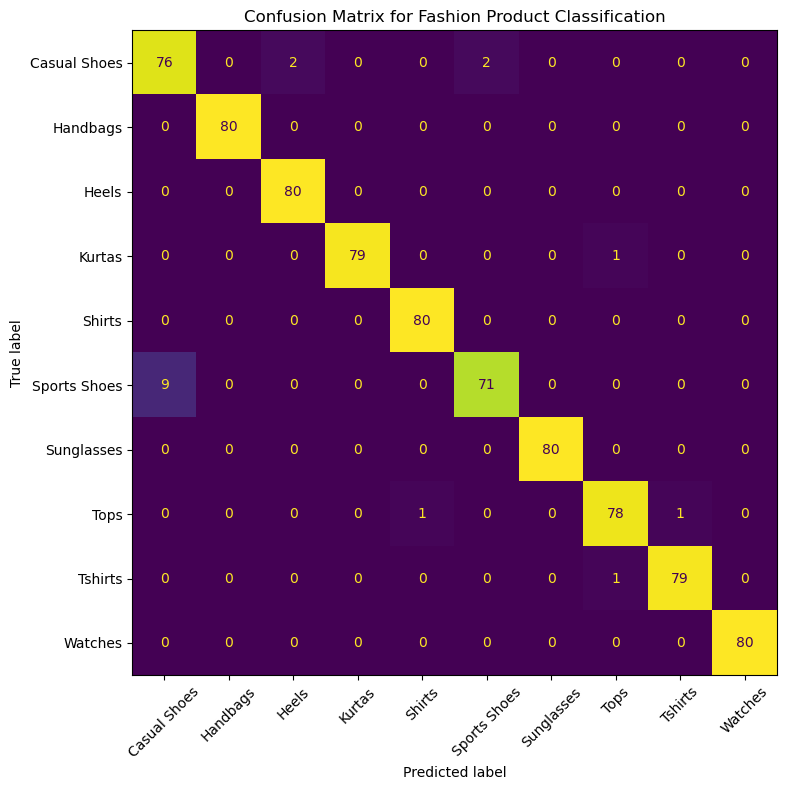

In [12]:
# Optional: confusion matrix for additional analysis
cm = confusion_matrix(true_labels, predicted_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("Confusion Matrix for Fashion Product Classification")
plt.tight_layout()
plt.show()

# 17. Sample Predictions

The following examples test the fine-tuned model on a few custom fashion product names. This helps demonstrate how the model behaves on new inputs.

In [13]:
def predict_article_type(text):
    model.eval()
    encoded = tokenizer(
        str(text).lower().strip(),
        truncation=True,
        max_length=MAX_LENGTH,
        return_tensors="pt"
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    with torch.no_grad():
        logits = model(**encoded).logits

    predicted_id = int(torch.argmax(logits, dim=-1).item())
    return id2label[predicted_id]

sample_products = [
    "slim fit cotton shirt for men",
    "elegant floral summer dress",
    "women black leather handbag",
    "running sneakers with mesh upper",
    "casual blue denim jeans"
]

for product in sample_products:
    print(f"{product} -> {predict_article_type(product)}")

slim fit cotton shirt for men -> Shirts
elegant floral summer dress -> Tops
women black leather handbag -> Handbags
running sneakers with mesh upper -> Casual Shoes
casual blue denim jeans -> Casual Shoes


# 18. PCA Visualization of Fashion Word Embeddings

To satisfy the PCA requirement, at least 20 known fashion-related words are converted into vector representations and reduced to two dimensions using Principal Component Analysis (PCA). The plot below visualizes the relative positions of these fashion words in embedding space.

You should take a screenshot of this graph for your submission.

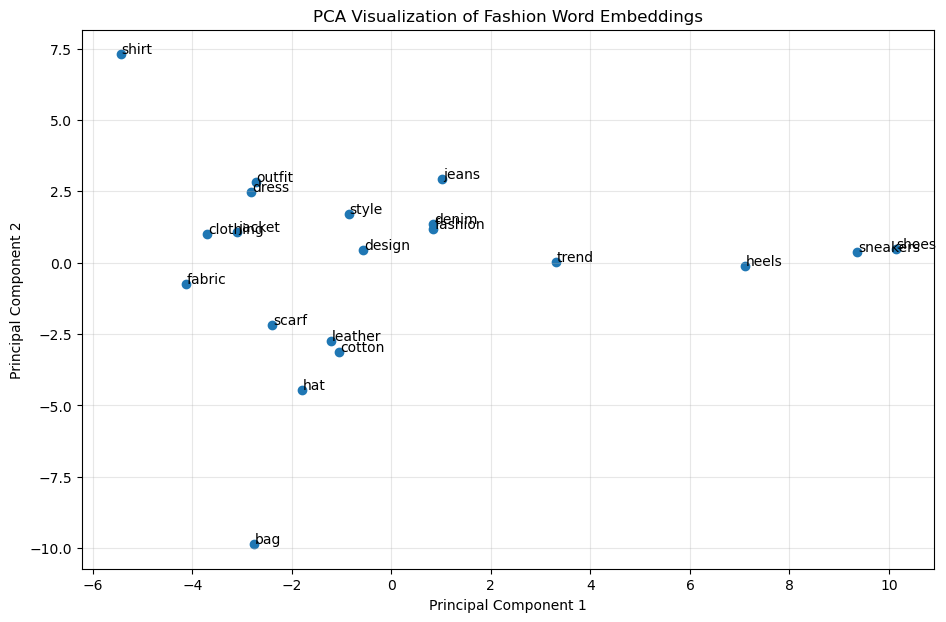

In [14]:
fashion_words = [
    "shirt", "dress", "jeans", "jacket", "shoes",
    "sneakers", "heels", "bag", "hat", "scarf",
    "fashion", "style", "design", "clothing", "outfit",
    "fabric", "cotton", "denim", "leather", "trend"
]

# Use the fine-tuned base encoder to obtain contextual word embeddings
if hasattr(model, "get_base_model"):
    base_model = model.get_base_model()
else:
    base_model = getattr(model, "base_model", None)
    if base_model is None and hasattr(model, "base_model_prefix"):
        base_model = getattr(model, model.base_model_prefix, None)
    if base_model is None:
        raise AttributeError("Could not locate base encoder in the loaded model")

embeddings = []

for word in fashion_words:
    inputs = tokenizer(word, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        outputs = base_model(**inputs)

    # Mean pooling over token embeddings
    vector = outputs.last_hidden_state.mean(dim=1).squeeze().detach().cpu().numpy()
    embeddings.append(vector)

embeddings = np.array(embeddings)

pca = PCA(n_components=2, random_state=42)
reduced_embeddings = pca.fit_transform(embeddings)

plt.figure(figsize=(11, 7))
plt.scatter(reduced_embeddings[:, 0], reduced_embeddings[:, 1])

for i, word in enumerate(fashion_words):
    plt.text(reduced_embeddings[i, 0] + 0.02, reduced_embeddings[i, 1] + 0.02, word, fontsize=10)

plt.title("PCA Visualization of Fashion Word Embeddings")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.grid(True, alpha=0.3)
plt.show()

# 19. Conclusion

This notebook successfully demonstrated the fine-tuning of a pretrained Hugging Face model for a domain-specific natural language processing task. The selected task was **fashion product classification**, the chosen domain was **fashion / e-commerce**, and the pretrained model used was **DistilBERT (`distilbert-base-uncased`)**.

The model was fine-tuned using a lightweight training configuration appropriate for a classroom setting. Performance was measured using **accuracy, precision, recall, and weighted F1-score**. In addition, fashion-related word vectors were visualized using **PCA**, satisfying the vector visualization requirement of the activity.

Overall, the project shows how pretrained language models can be adapted for a specialized real-world domain using a labeled dataset from Hugging Face.